In [2]:

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import silhouette_score

In [ ]:
# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.shape

(200, 5)

In [9]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [11]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

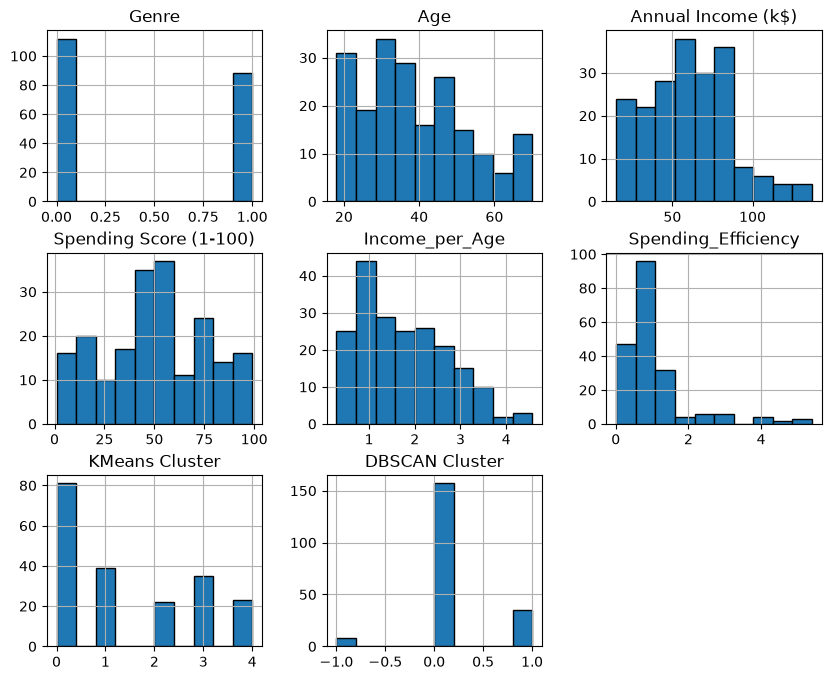

In [42]:
df.hist(figsize=(10,8),edgecolor='black')
plt.show()

<Axes: xlabel='Genre', ylabel='count'>

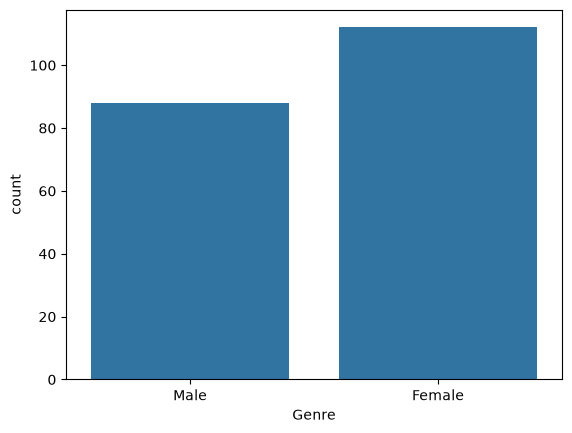

In [14]:
sns.countplot(x='Genre',data=df)

<Axes: >

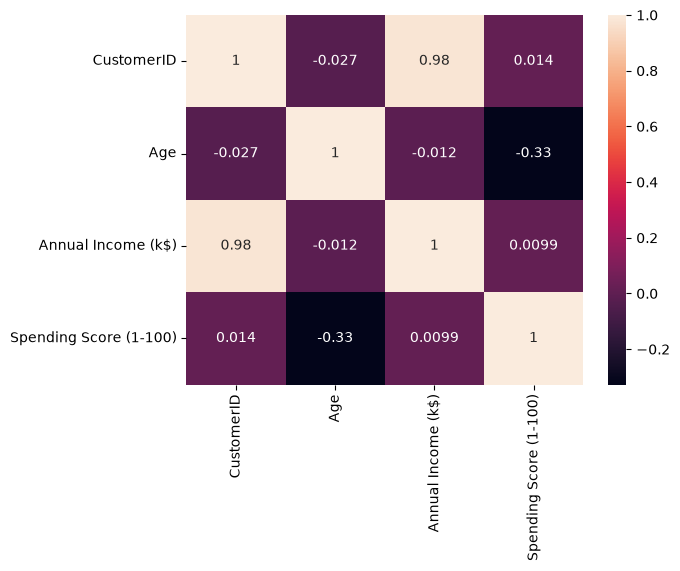

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

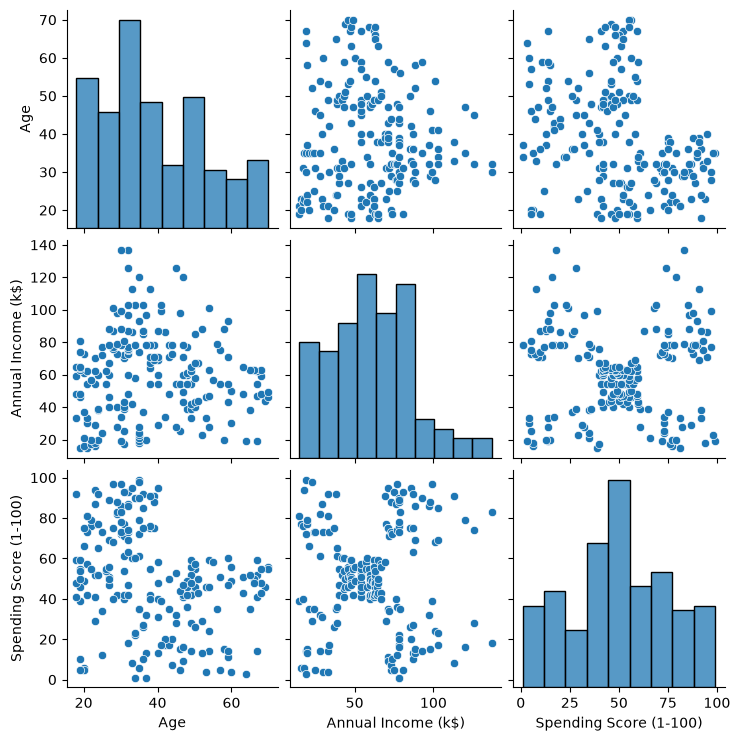

In [35]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.show()

In [17]:
df=df.drop('CustomerID',axis=1)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])

In [19]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [21]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaled_data=scaler.fit_transform(df)

In [22]:
df['Income_per_Age'] = df['Annual Income (k$)'] / df['Age']

In [23]:
df['Spending_Efficiency'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']

In [24]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

In [25]:
X = scaler.fit_transform(X)

In [26]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,
                    random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method')

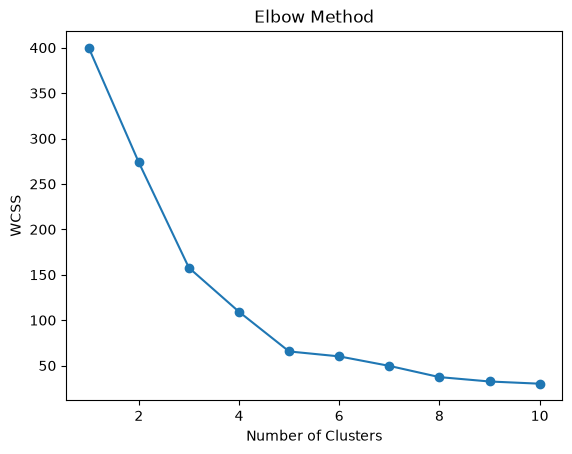

In [27]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

In [28]:
kmeans = KMeans(n_clusters=5,
                random_state=42)

clusters = kmeans.fit_predict(X)

df['KMeans Cluster'] = clusters

Text(0.5, 1.0, 'KMeans Clustering')

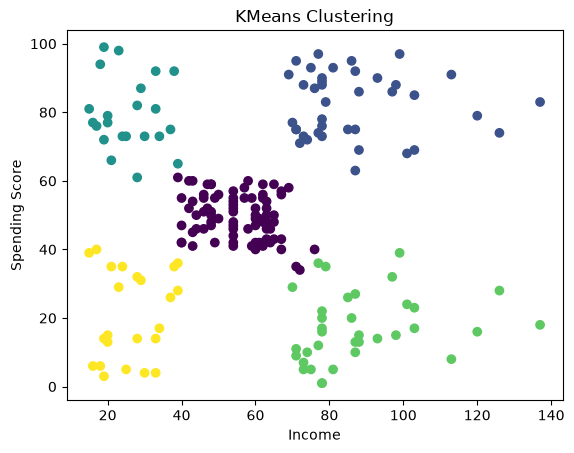

In [29]:
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['KMeans Cluster'])

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("KMeans Clustering")

In [30]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=0.5,
    min_samples=5
)

labels = db.fit_predict(X)

df['DBSCAN Cluster'] = labels

Text(0.5, 1.0, 'DBSCAN Clustering')

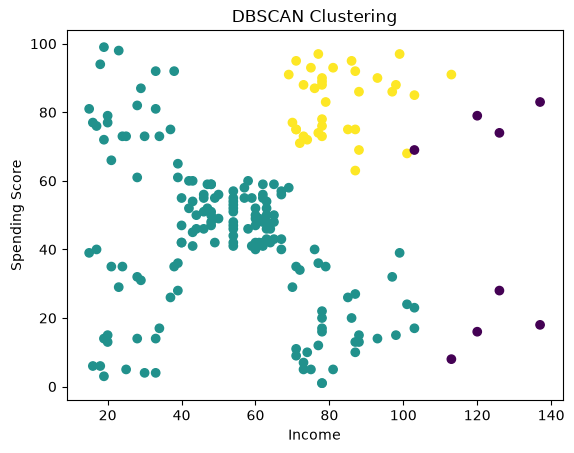

In [31]:
plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'],
            c=df['DBSCAN Cluster'])

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering")

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)

print(score)

0.5546571631111091


In [33]:
score = silhouette_score(
    X,
    labels
)